# 03 · 트리 벤치마크 (LightGBM + XGBoost)

> 역할: 딥러닝이 아닌 그래디언트 부스팅 트리(GBDT)로 성능의 '상한선'을 잡는다.
> 정형 스냅샷 데이터에선 트리가 보통 매우 강하므로, 04~07의 딥러닝 모델이
> 이 선을 따라잡는지 보는 기준선이 된다. (권준한님 노트북 연장선)

LightGBM, XGBoost 둘 다 같은 데이터·같은 지표로 평가해 results.csv에 함께 쌓는다.

## 0. 환경 설정
- **LightGBM / XGBoost**: 둘 다 GBDT(그래디언트 부스팅 결정트리) 라이브러리. 트리를 순차적으로
  쌓아 이전 트리의 오차를 보정한다. 정형 데이터의 분류·회귀·랭킹에 폭넓게 쓰이고, 결측 자동 처리·
  GPU·피처 중요도 등을 지원한다.
- **SHAP**: 모델의 예측을 '각 변수가 얼마나 밀고 당겼는지'로 분해해 설명하는 라이브러리(게임이론 기반).
  어떤 모델에도 쓰지만 트리에는 빠른 전용 계산(TreeExplainer)이 있다. 해석·디버깅·신뢰성 확보의 표준 도구.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
import shap

from utils import set_seed, compute_metrics, log_result, load_processed
set_seed(42)

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR     = PROJECT_ROOT / "processed"
RESULTS_CSV = PROJECT_ROOT / "notebooks_v1" / "results.csv"
print("준비 완료")

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


준비 완료


## 1. 데이터 불러오기
02에서 만든 데이터를 그대로 사용한다. 신경망과 달리 트리는 DataFrame을 바로 먹고,
스케일링도 필요 없다(이미 표준화돼 있어도 트리 결과는 변하지 않음 - 값의 순서만 보기 때문).

In [2]:
train_df, val_df, test_df = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_val   = val_df[feature_cols]
y_val   = val_df[TARGET]

print("피처 수:", len(feature_cols), " train 양성:", int(y_train.sum()), "/", len(y_train))

피처 수: 33  train 양성: 9034 / 1350288


## 2. 불균형 대응 (트리 버전)
신경망에서 가중치·Focal을 썼듯, 트리에는 `scale_pos_weight` 한 개면 된다.
소수 클래스(Yes)의 오답에 그만큼 더 큰 벌점을 준다.

In [3]:
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight = n_neg / n_pos
print("scale_pos_weight =", round(pos_weight, 1), " (No가 Yes보다 그만큼 많음)")

scale_pos_weight = 148.5  (No가 Yes보다 그만큼 많음)


## 3. LightGBM 학습
leaf-wise 성장 + 히스토그램 비닝으로 대용량(168만 행)도 빠르게 학습한다.
학습 후 val 확률을 뽑아 동일 지표로 채점하고 results.csv에 기록.

In [4]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)

lgb_prob = lgb_model.predict_proba(X_val)[:, 1]
lgb_metrics = compute_metrics(y_val, lgb_prob)
log_result("LightGBM", lgb_metrics, path=str(RESULTS_CSV))
print("LightGBM ", lgb_metrics)
np.save(PROJECT_ROOT / "notebooks_v1" / "lgb_val_prob.npy", lgb_prob)

LightGBM  {'PR_AUC': 0.2237, 'ROC_AUC': 0.958, 'Recall': 0.8907, 'Precision': 0.0557, 'F1': 0.1048, 'threshold': 0.5}


## 4. XGBoost 학습
같은 GBDT지만 엔지니어링이 다른 '사촌'. 비슷한 설정으로 학습해 LightGBM과 교차검증한다.
두 트리가 비슷한 성능을 주면 '이 데이터에서 트리가 도달하는 수준'을 신뢰할 수 있다.

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_metrics = compute_metrics(y_val, xgb_prob)
log_result("XGBoost", xgb_metrics, path=str(RESULTS_CSV))
print("XGBoost  ", xgb_metrics)
np.save(PROJECT_ROOT / "notebooks_v1" / "xgb_val_prob.npy", xgb_prob)

XGBoost   {'PR_AUC': 0.2438, 'ROC_AUC': 0.9618, 'Recall': 0.8836, 'Precision': 0.0598, 'F1': 0.112, 'threshold': 0.5}


## 5. 결과 비교표
results.csv를 불러와 비교. (04를 먼저 돌렸다면 MLP 행도 함께 보인다.)
PR_AUC가 높을수록 소수 클래스를 잘 잡는 것.

In [6]:
res = pd.read_csv(RESULTS_CSV)
res = res.drop_duplicates(subset="model", keep="last")
res[["model", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1"]]

,model,PR_AUC,ROC_AUC,Recall,Precision,F1
0,MLP_1_plain_BCE,0.1859,0.9411,0.0217,0.4298,0.0413
1,MLP_2_weighted,0.1662,0.9469,0.8907,0.0451,0.0859
2,MLP_3_focal,0.1927,0.9463,0.1983,0.3109,0.2422
3,MLP_4_focal_dropout,0.1859,0.9421,0.1301,0.3387,0.1880
4,MLP_5_focal_drop_bn,0.1638,0.9443,0.0044,0.2041,0.0087
5,MLP_6_undersample,0.1239,0.9328,0.7627,0.0625,0.1156
9,FT_Transformer,0.1446,0.9338,0.0713,0.2800,0.1136
13,TabNet,0.0932,0.9193,0.9172,0.0241,0.0470
14,AE_anomaly,0.0250,0.7028,0.0000,0.0000,0.0000
15,LightGBM,0.2237,0.9580,0.8907,0.0557,0.1048


## 6. SHAP - 어떤 변수가 백오더를 끌어올리나
더 좋은 트리를 골라 SHAP로 변수 기여도를 본다.
summary plot에서 점 하나가 샘플 하나다. 가로축이 오른쪽(양수)일수록 그 샘플의 백오더 확률을
**올리는** 방향, 왼쪽이면 내리는 방향. 점 색은 그 변수의 값(빨강=큼, 파랑=작음).
예상대로 재고 부족·지역 백오더 관련 변수가 위로 올라오는지 확인한다.
(전체에 SHAP는 느리므로 val에서 5000개만 샘플)

SHAP 대상: XGBoost


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27192\7513988.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, show=True)


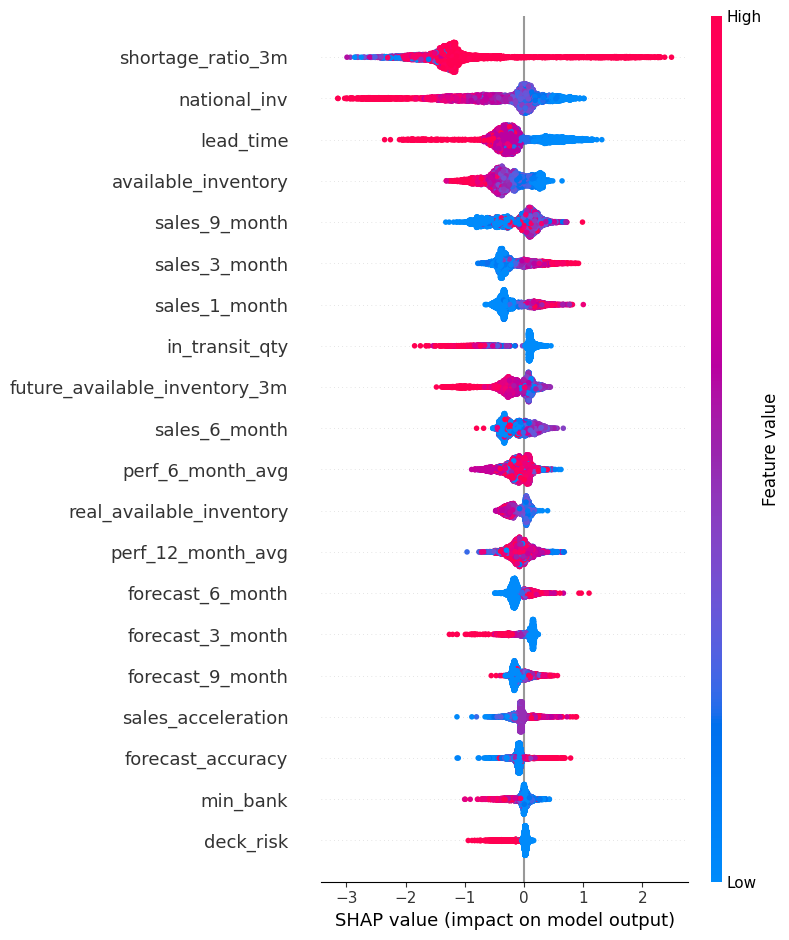

In [7]:
if lgb_metrics["PR_AUC"] >= xgb_metrics["PR_AUC"]:
    best_name, best_model = "LightGBM", lgb_model
else:
    best_name, best_model = "XGBoost", xgb_model
print("SHAP 대상:", best_name)

sample = X_val.sample(5000, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):   # 일부 버전은 [음성, 양성] 리스트로 반환
    shap_values = shap_values[1]

shap.summary_plot(shap_values, sample, show=True)

---
### 정리
- LightGBM, XGBoost 두 GBDT를 같은 데이터·같은 지표로 평가해 results.csv에 기록.
- 이 둘은 비-딥러닝 '성능 상한선' 벤치마크. 딥러닝 모델(04 MLP, 05 Transformer, 06 TabNet, 07 AE)이
  이 선을 따라잡는지 보는 기준이다.
- SHAP은 어떤 변수가 백오더 위험을 끌어올리는지 보여준다 -> 파생변수 선택 근거로 재활용 가능.

정형 스냅샷 데이터에선 보통 트리가 강하다. 딥러닝이 못 이겨도 '왜 그런가'를 논하는 게 08의 핵심 포인트.